##**Week 3 Assignment: Visualization & Linear Regression**

Iris Wu


###**Libraries & Dataset**

In [36]:
#load the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
#load the dataset
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


###**Part I: Visualization**

####**A. Scatterplots & Aesthetics**

1. Scatterplot of size vs. price:

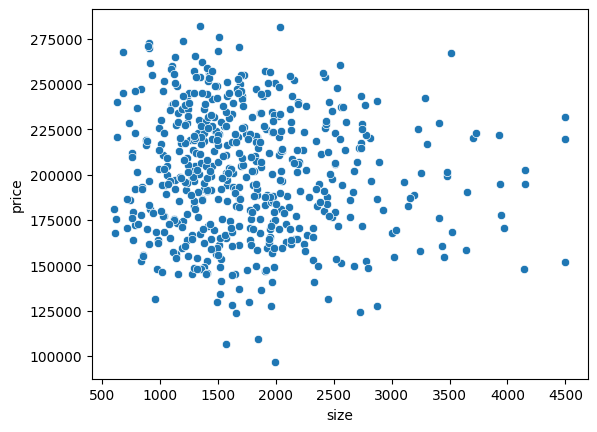

In [38]:
sns.scatterplot(data=df, x = "size", y = "price")
plt.show()

2. Recreate the plot with neighborhood added:

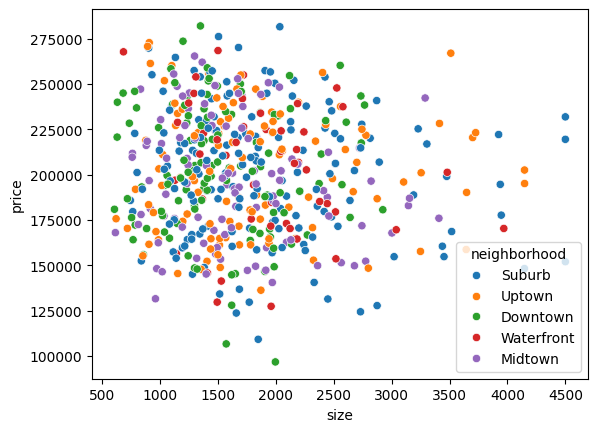

In [39]:
sns.scatterplot(data = df, x = "size", y = "price", hue = "neighborhood")
plt.show()

3. Use transparency to reduce overplotting:

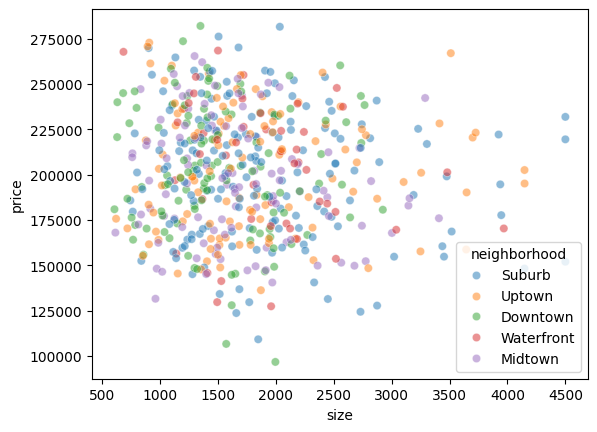

In [40]:
sns.scatterplot(data = df, x = "size", y = "price", hue = "neighborhood", alpha = 0.5)
plt.show()

**Short Answers**

1. Seaborn automatically creates the plot legend and axes labels by pulling directly from the dataframe. With matplotlib, the axes labels and legend must be created manually. Seaborn is better at reading dataframes.

2. When there are too many datapoints,it can be hard to interpret a plot. By adding transparency, it is easier to read the plot and identify overlapping datapoints.

####**B. Small Multiples (Faceting)**

Create small multiples of size vs price, separated by `bedrooms`.


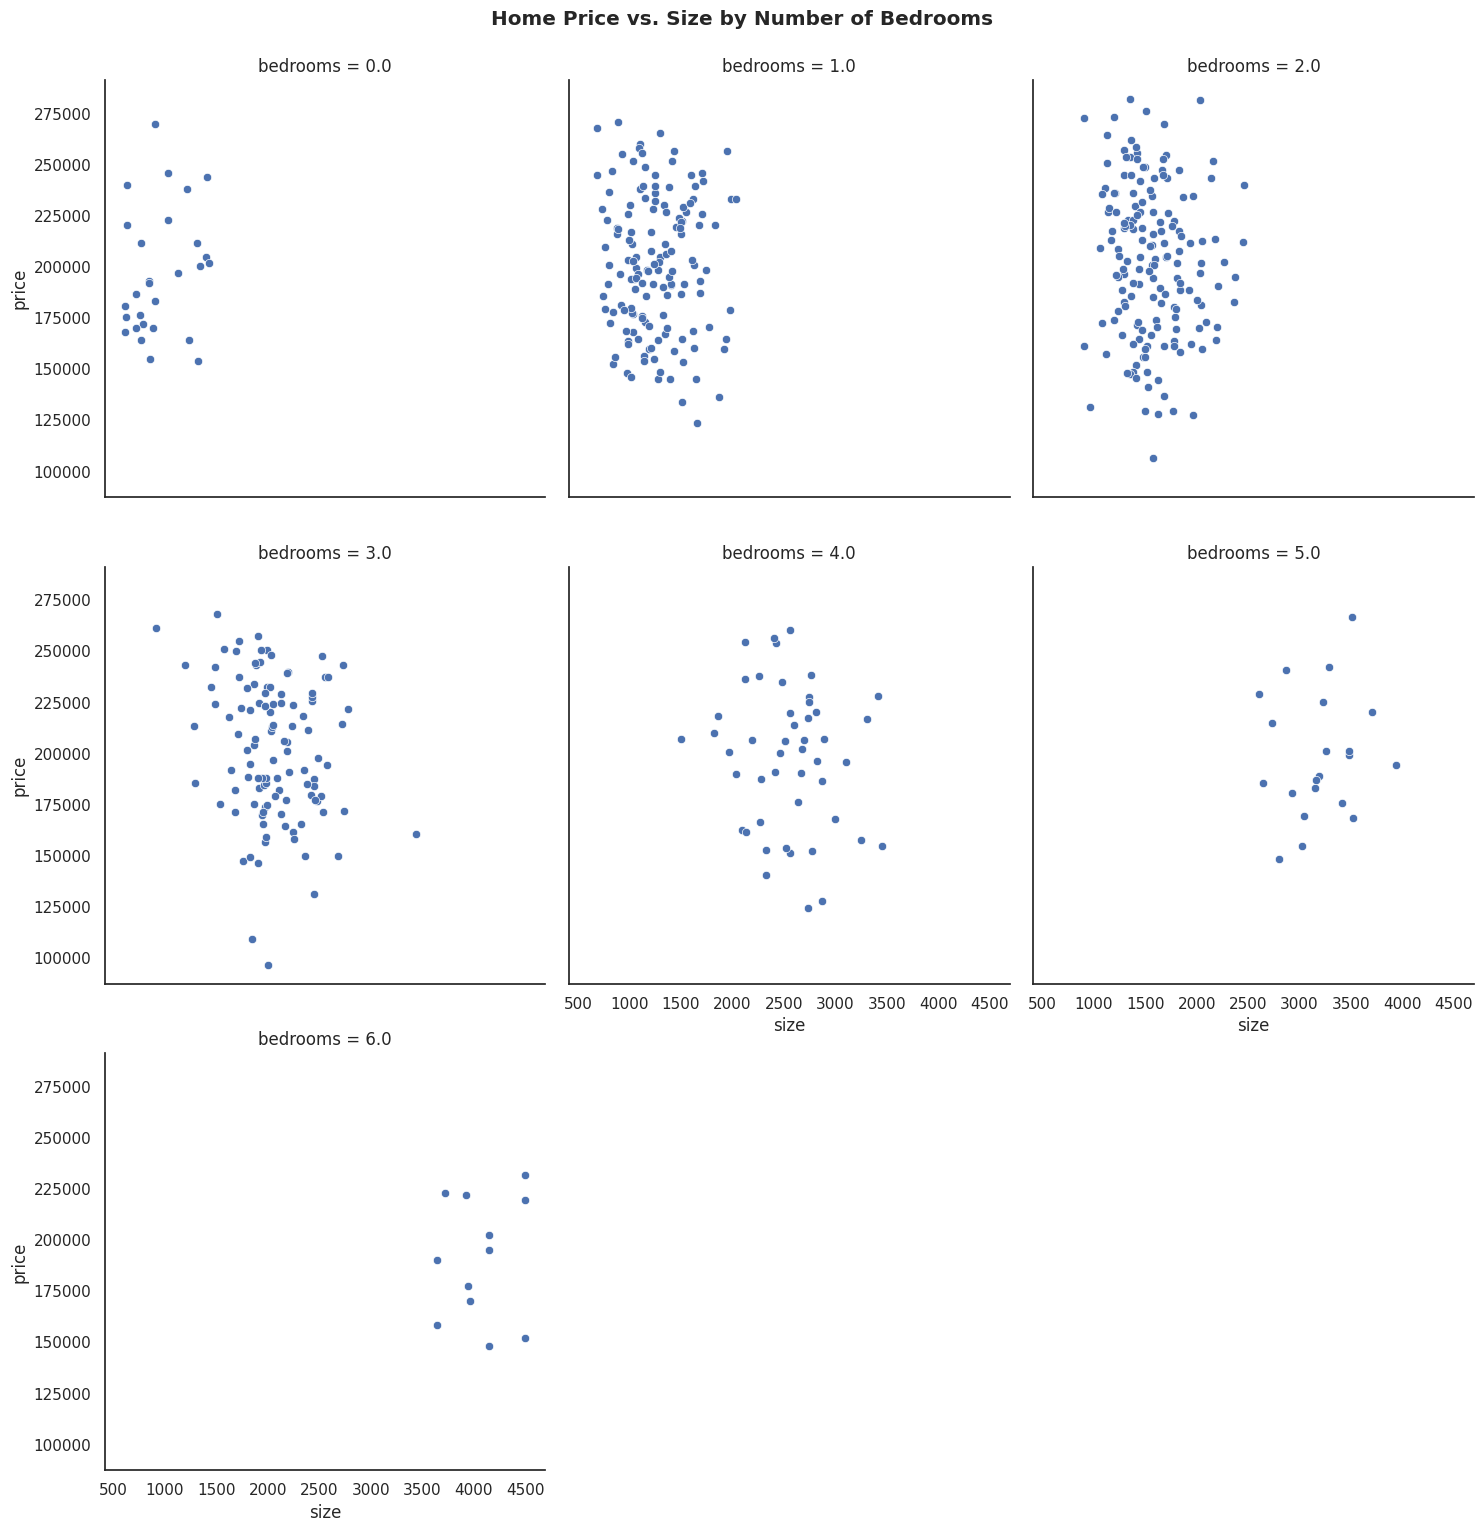

In [64]:
sns.relplot(data = df, x = "size", y = "price" , col = "bedrooms", col_wrap = 3)
plt.suptitle("Home Price vs. Size by Number of Bedrooms", y = 1.02, fontweight = "bold")
plt.show()

 While the size of the house increases as the number of bedrooms increase, there is no clear correlation between size and price.

####**C. Distribution and Categorical Plots**

1. Create a histogram of `price`:

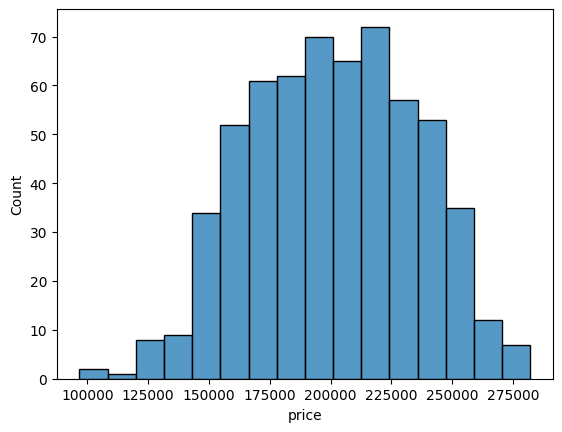

In [32]:
sns.histplot(data = df, x = "price")
plt.show()

2. Create a density plot of `price`:

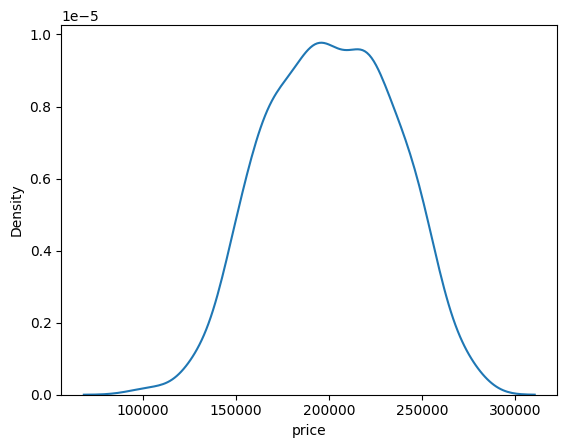

In [33]:
sns.kdeplot(data = df, x = "price")
plt.show()

3. Create a boxplot of `price` by `neighborhood`:

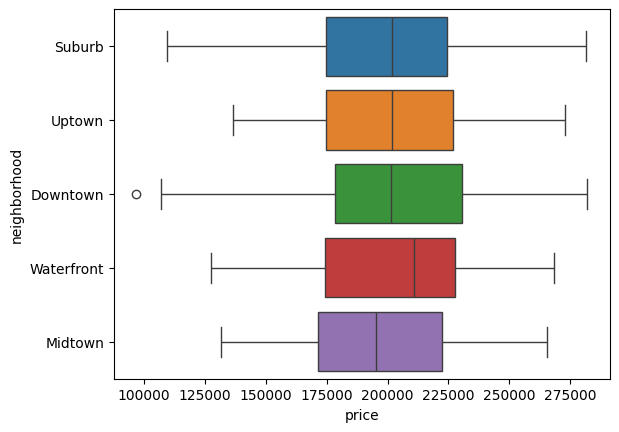

In [34]:
sns.boxplot(data = df, x = "price", y = "neighborhood", hue = "neighborhood")
plt.show()

**Interpretation**

The neighborhoods do not differ greatly in price. Median prices in each neighborhood fall around $2000000. The Waterfront has a higher median price of around 225000, but it is not significantly more expensive than the rest of the neighborhoods. Of all the neighborhoods, Downtown and Suburb have the widest range of prices, with one outlier at the lower end in Downtown.

###**Part II: Linear Regression for Inference**

**A. Multiple Regression (R to Python)**

In R, the model would be:

`lm(price ~ size + bedrooms + neighborhood, data = df)`

In Python:

In [35]:
model_housing = smf.ols("price ~ size + bedrooms + neighborhood", data = df).fit()
model_housing.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.190
Time:                        00:57:37   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
neighborhood[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
neighborhood[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
neighborhood[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
neighborhood[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                         -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                    4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**B. Interpretation**

 1. The coefficient for size is -10.935. For each square foot increase in the size of a house, the price decreases by $10.935, with all other predictors (neighborhood and number of bedrooms) held constant. This seems counterintuitive and may signify abnormalities in the data.

 2. Size is statistically significant because its p-value is 0.01, which is less than 0.05.

 3. According to the R-squared, only 1.7% of the variance in home prices can be explained by the model. This indicates the current model is very weak at predicting home prices.



###**Part III: Prediction Workflow**

1. Split the data into training and test sets:

In [46]:
#remove NAs from the columns
df_clean = df.dropna(subset = ["size", "bedrooms", "price"])

#change "neighborhood" into a numerical variable (I used Google Gemini 3 for help with this code)
X = df_numerical = pd.get_dummies(df_clean, columns = ["neighborhood"], drop_first = True)

#assign X and y
X = df_numerical.drop(["price", "type"], axis = 1)
y = df_numerical["price"]



2. Fit linear regression



In [48]:
#create the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 0)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

3. Find RMSE and R-squared



In [67]:
#get the model's predictions
y_pred = model.predict(X_test)

#compare the model with the actual data
df_compare = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(df_compare.head())

#calculate r-squared
r2 = r2_score(y_test, y_pred)

#calculate RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.4f}")
print(f"RMSE: ${rmse: ,.2f}")



       Actual      Predicted
583  226791.0  242756.475706
17    96746.0  156846.875991
526  217820.0  238304.796650
154  177470.0  180412.856821
457  216232.0  228891.915229
R-squared: 0.6314
RMSE: $ 19,643.37


**Short Answer**

1. `scikit-learn` does not report p-values because it is used for machine learning rather than statistical inference. Machine learning focuses on providing accurate predictions. P-values indicate the relationship between two variables, but they do not reveal the accuracy of a prediction, so it is not useful for `scikit-learn` to report them.

2. For explanation, I would use statsmodel, since it calculates p-values; for prediction I would use scikit-learn.

3. The goal of explanation is to find and evaluate the relationship between multiple variables, while the goal of prediction is to use past data to make an accurate educated guess about future outcomes.

###**Part IV: Integrated Thinking**


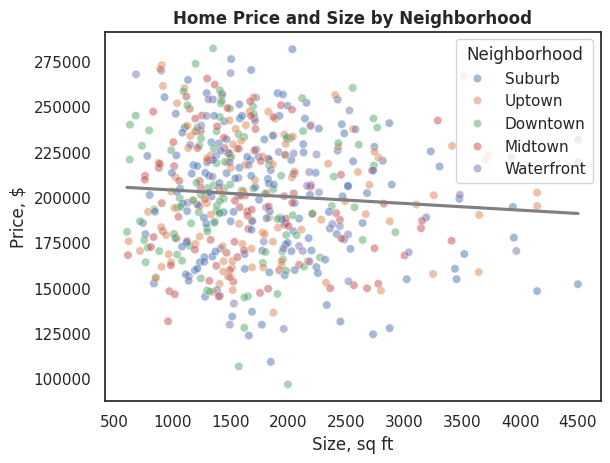

In [63]:
sns.set_theme(style = "white", font = "sans-serif")

sns.scatterplot(data = df_clean, x = "size", y = "price", hue = "neighborhood", alpha = 0.5)
sns.regplot(data = df_clean, x = "size", y = "price", scatter = False, color = "gray", ci = None)
sns.color_palette("Set2")
plt.title ("Home Price and Size by Neighborhood", fontweight = "bold")
plt.xlabel("Size, sq ft")
plt.ylabel("Price, $")
plt.legend(title = "Neighborhood")
plt.show()


The linear regression model reported a small r-squared of 0.017 and a coeffiecent of -10.9345. These results indicate a weak correlation and inverse relationship between home price and size. The visualization both anticipates and confirms the model results. On the plot, the regression line has a negative slope, and the data points are spread loosely instead of clustered around the line.